# Machine Learning in Python - Project 1

## Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['figure.dpi'] = 80

import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, PolynomialFeatures, FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline, FeatureUnion, make_pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [2]:
def model_fit(m, X, y, plot = False):
    """Returns the mean squared error, root mean squared error and R^2 value of a fitted model based 
    on provided X and y values.
    
    Args:
        m: sklearn model object
        X: model matrix to use for prediction
        y: outcome vector to use to calculating rmse and residuals
        plot: boolean value, should fit plots be shown 
    """
    
    y_hat = m.predict(X)
    MSE = mean_squared_error(y, y_hat)
    RMSE = np.sqrt(mean_squared_error(y, y_hat))
    Rsqr = r2_score(y, y_hat)
    
    Metrics = (round(MSE, 4), round(RMSE, 4), round(Rsqr, 4))
    
    res = pd.DataFrame(
        data = {'y': y, 'y_hat': y_hat, 'resid': y - y_hat}
    )
    
    if plot:
        plt.figure(figsize=(10, 5))
        
        plt.subplot(121)
        sns.lineplot(x='y', y='y_hat', color="grey", data =  pd.DataFrame(data={'y': [min(y),max(y)], 'y_hat': [min(y),max(y)]}))
        sns.scatterplot(x='y', y='y_hat', data=res).set_title("Observed vs Fitted values")
        
        plt.subplot(122)
        sns.scatterplot(x='y_hat', y='resid', data=res).set_title("Fitted values vs Residuals")
        plt.hlines(y=0, xmin=np.min(y), xmax=np.max(y), linestyles='dashed', alpha=0.3, colors="black")
        
        plt.subplots_adjust(left=0.0)
        
        plt.suptitle("Model (MSE, RMSE, Rsq) = " + str(Metrics), fontsize=14)
        plt.show()
    
    return MSE, RMSE, Rsqr

In [61]:
d = pd.read_csv("adnidata.csv")

# Introduction

In this paper we aim to identify the key factors contributing to cognitive decline using the Alzheimer's Disease Asessment Scale-Cognitive Subscale (ADAS-Cog) 13. We will be working with data collected by the Alzheimer's Disease Neuroimaging Initiative. This data contains information such as baseline cognitive scores (ADAS13.bl), demographic information, APOE genotype, and brain volume measurements (e.g., hippocampus, whole brain volume).

Our approach is as follows, we begin by performing some exploratry data analysis to reveal any trends in the data. These findings can help us develop our initial (linear regression) model, which we then make slight improvements on using an alternative model (Lasso), which considers additional contributing factors.

# Exploratory Data Analysis and Feature Engineering
In this section we will perform some exploratory data analysis finding trends to help create our model in the next section. Taking a look at the data we find there are 1038 responses however, there seems to be some missing values for the following features: `APOE4`, `Ventricles`, `Hippocampus`, `WholeBrain`, `Entorhinal`, `Fusiform`, `MidTemp` and `ICV`. Since the relationships between the column data cannot be determined, we adopt the approach of directly removing the missing data. After removing rows with missing data, we have a total of 885 entries.

In [4]:
d_drop = d.dropna() 
X = d_drop.drop(columns=["Unnamed: 0", "ADAS13.m24"])
y = d_drop["ADAS13.m24"].copy()

The above code removes the row indicator and `ADAS13.m24` and adds it to our y data. 

We investigated for extreme values outside of the inter-quartile range for each numerical feature. Even though we won't be removing these we wanted to draw attention to additional steps we could take if we could consult experts. Before we perform any exploratory analysis, it is crucial we split our data into train and test data sets. We peform a 70:30 split to obtain our train and test data. This is important as once we make our model we want to be able to test it in order to perform any adjustments.

In [32]:
rng = np.random.seed(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = rng)

The above code splits our data into training and testing data using a random seed.

## Exploratory Data Analysis
Below is the histogram plot of test scores after 24 months. We see this is positiviely skewed, in order to get the best results we will transform this before fitting our model.

<Axes: xlabel='ADAS13.m24', ylabel='Count'>

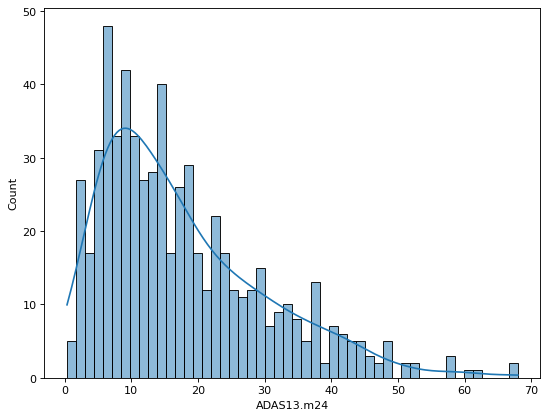

In [33]:
plt.figure(figsize=(8, 6)) 
sns.histplot(y_train, bins=50, kde=True)  

The above code plots the histogram for the training `ADAS13.m24` data.

Taking a look at the numerical variables, we can see positive skewes in both the baseline test scores (`ADAS13.bl`) as well as the volume of Ventricles (`Ventricles`). For this reason we will be performing a tranformation on these features before fitting our model. It is worth noting `APOE4` takes values $\{0,1,2\}$. After treating it as a binary variable (0 if `APOR4` is 0, and 1 otherwise) or an ordinal variable we observe no significant changes. So, from here we will treat it as a numerical variable. The other numerical features aren't significantly skewed so we will keep them unchanged.

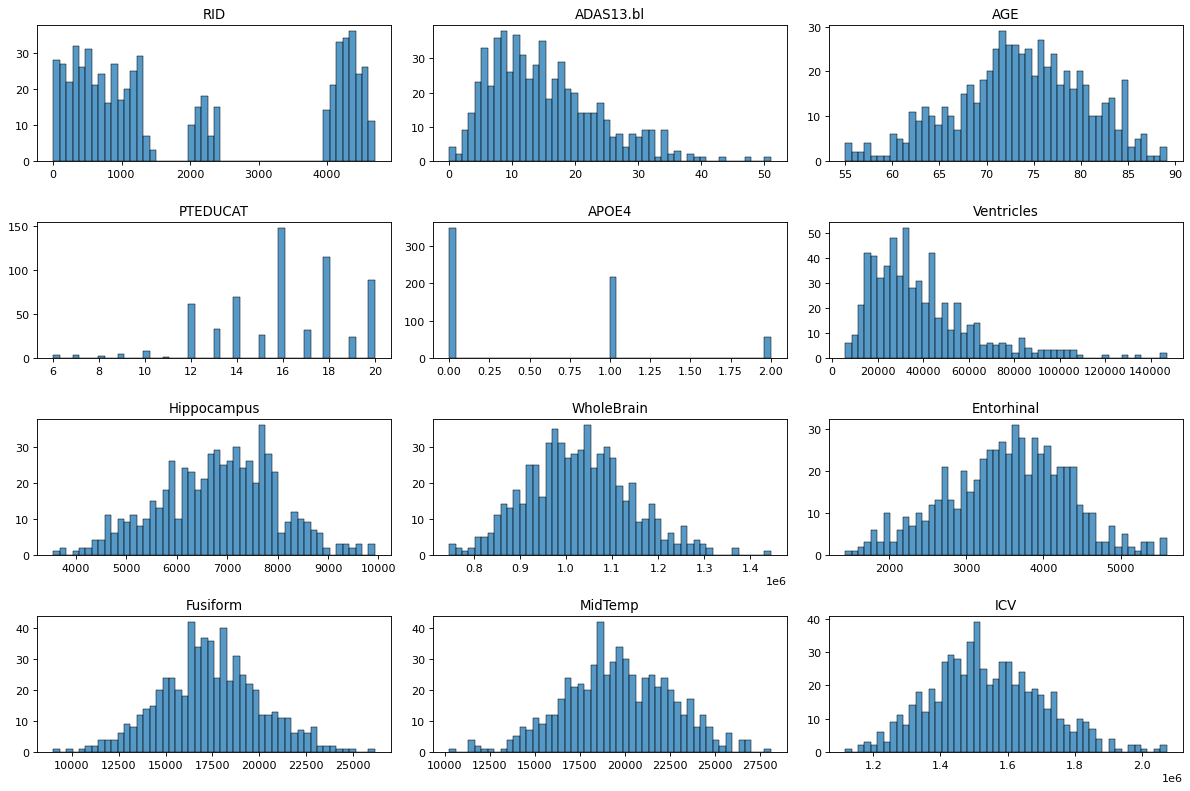

In [34]:
m = X_train.drop(columns=["DX.bl", "PTGENDER", "PTETHCAT", "PTRACCAT", "PTMARRY"])
fig, axes = plt.subplots(figsize = (15,10), ncols = 3, nrows = 4)
axes = axes.flatten()
for i, ax in enumerate(axes):
    sns.histplot(data = m.iloc[:, i], bins=50, ax=ax)
    ax.set_title(m.iloc[:,i].name)
    ax.set_ylabel("")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

The above code plots the histograms for each of the numerical variables.

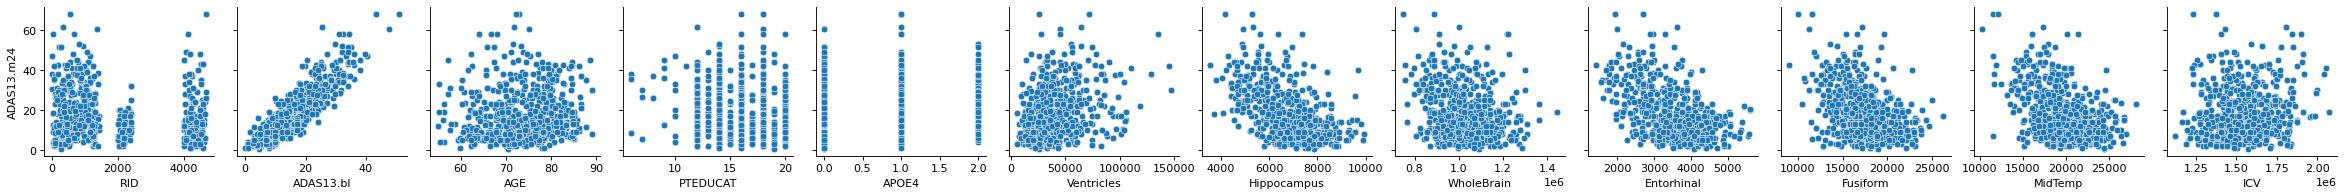

In [35]:
df = pd.concat([m, y_train], axis=1)
g = sns.PairGrid(df, x_vars=m.columns, y_vars=["ADAS13.m24"])
g.map(sns.scatterplot)
plt.show()

The above code plots the distributions of `ADAS13.m24` against all of our features. 

To ensure we account for any potential polynomial relationships between the features and the response we can use the pair-plot. As we can see there are no obvious non-linear relationships. This will inform our decisions later about including polynomial regression models.

The heatmap below can give us insight into which features are correlated with our response variable `ADAS13.m24`. We see there are high positive correlations with features `ADAS13.bl`, `APOE4` and `Ventricles`. Additionally there are strong negative correlations with features `Hippocampus`, `Entorhinal`, `Fusiform` and `MidTemp`. This will be used to justify the choices we make in creating our baseline model.

<Axes: >

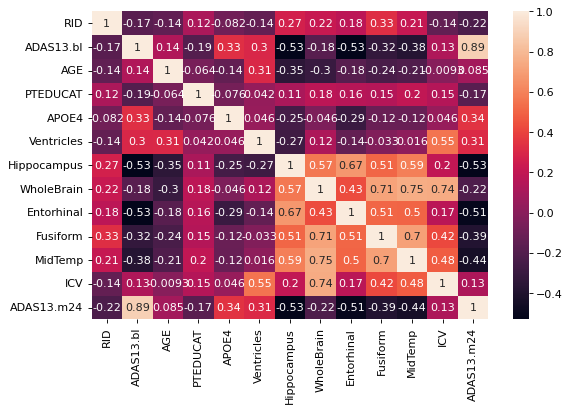

In [36]:
sns.heatmap(pd.concat([m, y_train], axis=1).corr(numeric_only=True),annot=True)

The above code plots a correlation heat map of all of the available features and response variables.

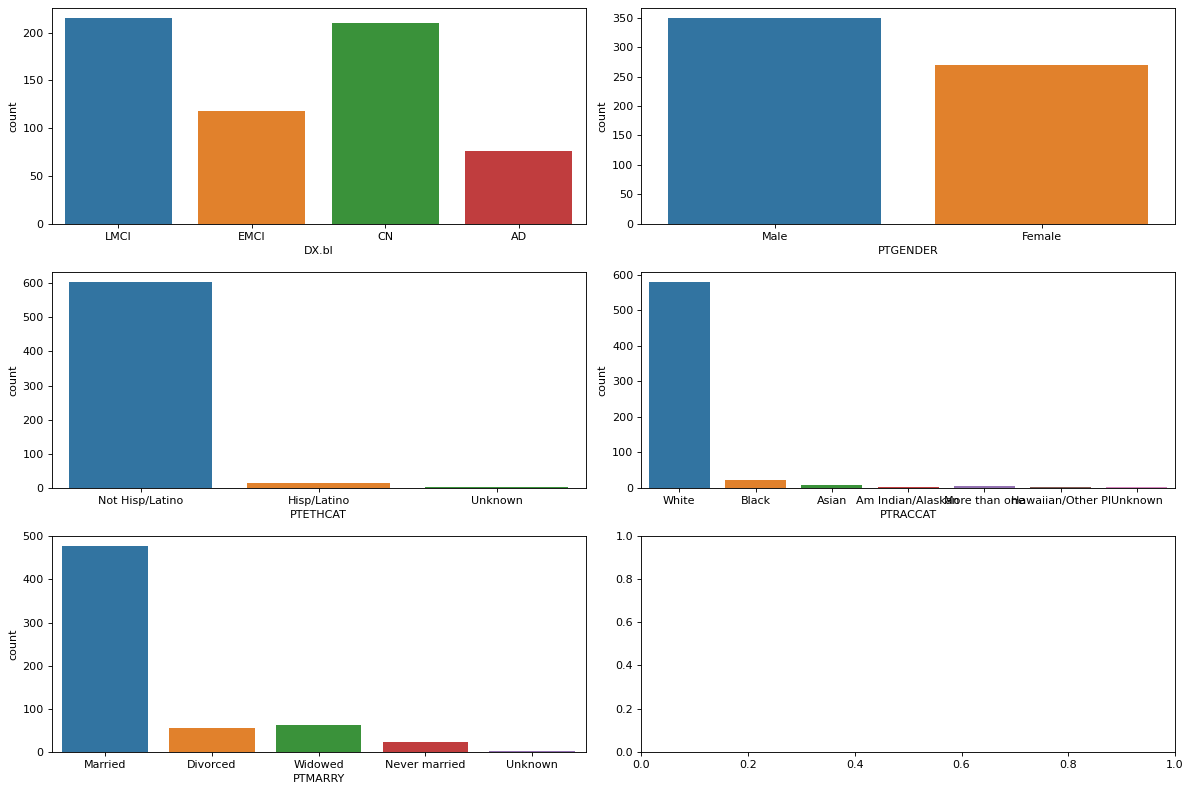

In [37]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))
categories = ["DX.bl", "PTGENDER", "PTETHCAT", "PTRACCAT", "PTMARRY"]

for i, cat in enumerate(categories):
    row, col = divmod(i, 2)
    sns.countplot(data=X_train, x=cat, ax=axes[row, col])
plt.tight_layout()
plt.show()

The above code shows the counts for each categorical variable. 

Now we can investigate the categorical features from out data. Taking a look at the counts for each category, we found the only variables that aren't highly skewed are `DX.bl` and `PTGENDER`. For this reason these are the only categorical variables we will consider in the variable selction for our initial linear regression model.

## Feature Engineering

Now we will discuss how we transformed the numerical and categorical variables discussed in the EDA. Firstly, we will be using a Box-Cox transformation on the features `ADAS13.m24`, `ADAS13.bl` and `Ventricles`. Below we transform each variable for a range of $\lambda$, taking $\lambda$ as 0.3, 0.5 and 0.2 for `ADAS13.m24`, `ADAS13.bl` and `Ventricles` respectively. This ensures these features have distribution that more closely resembels a normal distribution.

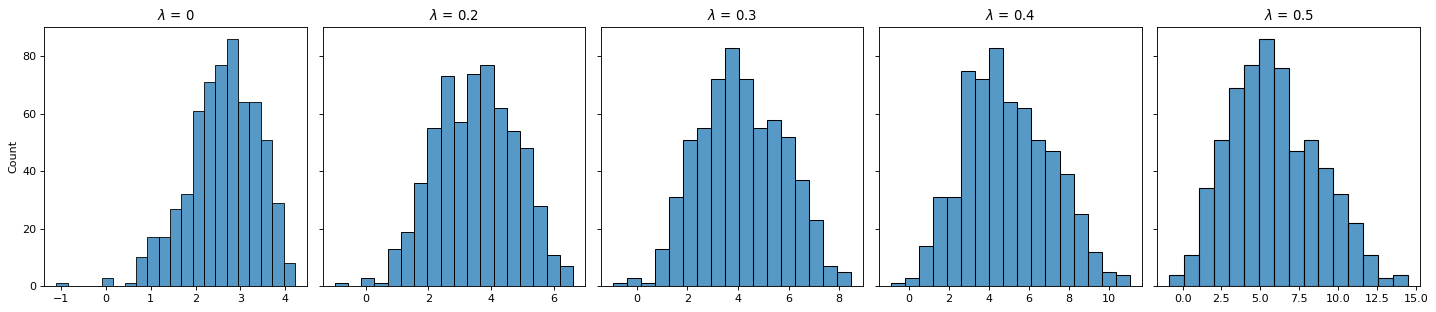

In [38]:
fig, axes = plt.subplots(figsize = (18,4), ncols = 5, nrows=1, sharey = True)
axes = axes.flatten()
for i, lmbda in enumerate([0, 0.2, 0.3, 0.4, 0.5]):
    y_box_ = stats.boxcox(y_train.astype(float), lmbda = lmbda)
    sns.histplot(data = y_box_, ax = axes[i])
    axes[i].set_title("$\lambda$ = {}".format(lmbda))
plt.tight_layout()
plt.show()

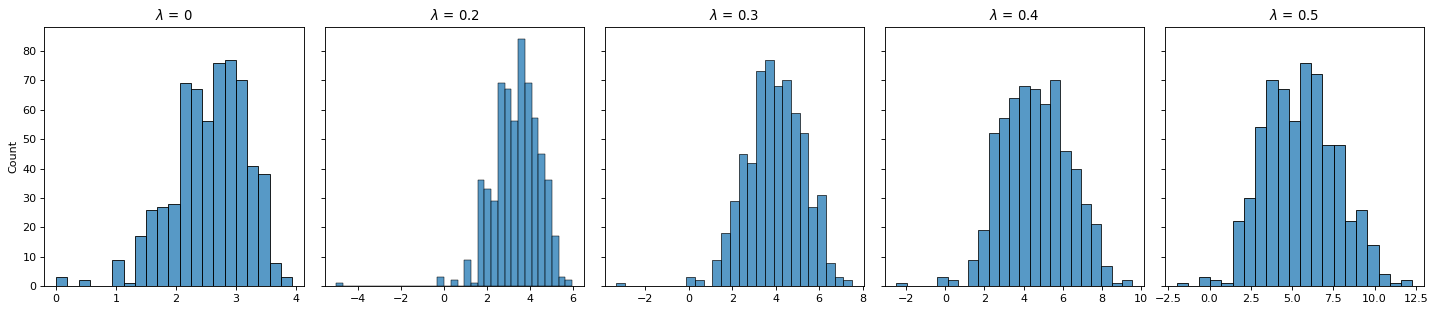

In [39]:
fig, axes = plt.subplots(figsize = (18,4), ncols = 5, nrows=1, sharey = True)
axes = axes.flatten()
for i, lmbda in enumerate([0, 0.2, 0.3, 0.4, 0.5]):
    X_ADAS_box_ = stats.boxcox(X_train["ADAS13.bl"].astype(float), lmbda = lmbda)
    sns.histplot(data = X_ADAS_box_, ax = axes[i])
    axes[i].set_title("$\lambda$ = {}".format(lmbda)) 
plt.tight_layout()
plt.show()

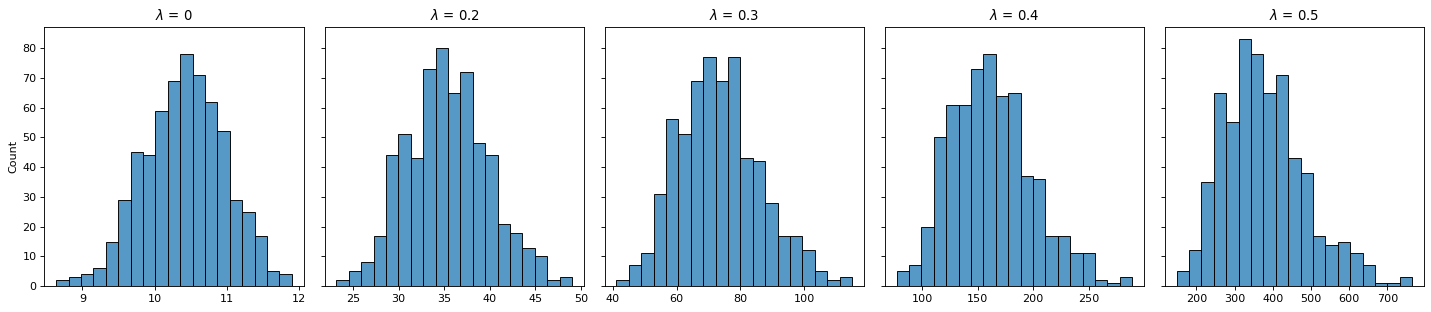

In [40]:
fig, axes = plt.subplots(figsize = (18,4), ncols = 5, nrows=1, sharey = True)
axes = axes.flatten()
for i, lmbda in enumerate([0, 0.2, 0.3, 0.4, 0.5]):
    X_Ven_box_ = stats.boxcox(X_train["Ventricles"].astype(float), lmbda = lmbda)
    sns.histplot(data = X_Ven_box_, ax = axes[i])
    axes[i].set_title("$\lambda$ = {}".format(lmbda))
plt.tight_layout()
plt.show()

The above code finds the resulting distributions for `ADAS13.m24`, `ADAS13.bl` and `Ventricles` respectively. 

In [41]:
y_train_box_ = stats.boxcox(y_train.astype(float), lmbda = 0.3)
y_test_box_ = stats.boxcox(y_test.astype(float), lmbda = 0.3)

X_train["ADAS13.bl"] = stats.boxcox(X_train["ADAS13.bl"].astype(float), lmbda = 0.5)
X_test["ADAS13.bl"] = stats.boxcox(X_test["ADAS13.bl"].astype(float), lmbda = 0.5)

X_train["Ventricles"] = stats.boxcox(X_train["Ventricles"].astype(float), lmbda = 0.2)
X_test["Ventricles"] = stats.boxcox(X_test["Ventricles"].astype(float), lmbda = 0.2)

The above code applies Box-Cox transformations using the best value of $\lambda$.

We will be performing a One-Hot encoding to `DX.bl`, to do so we will be using an Sklearn pipeline. Note that we also tested encoding `DX.bl` as an ordinal variable, however this hindered the performance of the model.

# Model Fitting and Tuning
In this section we will be fitting our baseline linear model with the features outlined previously, as well as developing a new lasso model which we can compare with our baseline. 

To begin with, we found that the feature `PTGENDER` did not contribute to the model so we removed it from our feature space. This resulted in our initial linear regression model as shown below. We also tried implementing interaction terms, however we didn't find any significant improvements.

In [42]:
num = ["ADAS13.bl", "APOE4", "Ventricles"]
cat = ["DX.bl"]
onehot_encoder = OneHotEncoder(handle_unknown='ignore')
encoder = ColumnTransformer([
    ("num", "passthrough", num), 
    ("cat", onehot_encoder, cat),]) 
X_train_1hot = encoder.fit_transform(X_train)
all_cols = list(num)+list(encoder.named_transformers_["cat"].get_feature_names_out())
X_train_1hot_df = pd.DataFrame(X_train_1hot,columns=all_cols)

The above code uses an Sklearn pipeline to use the One-Hot encoder to encode `DX.bl` and passes `ADAS13.bl` `APOE4`, `Ventricles` through unchanged.

In [43]:
X_test_1hot = encoder.transform(X_test)
all_cols = list(num)+list(encoder.named_transformers_["cat"].get_feature_names_out())
X_test_1hot_df = pd.DataFrame(X_test_1hot,columns=all_cols)

We repeat the last process for the testing data.

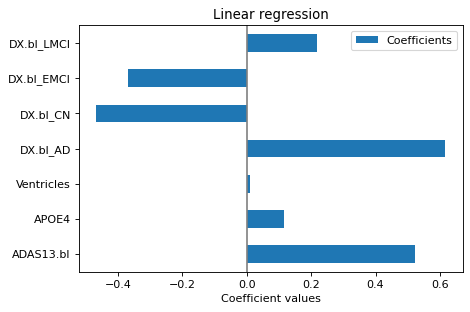

In [44]:
lm = LinearRegression().fit(X_train_1hot_df, y_train_box_)
fe_names = lm.feature_names_in_
coefs = pd.DataFrame(
    np.copy(lm.coef_),
    columns=["Coefficients"],
    index=fe_names,)
coefs.plot.barh(figsize=(8, 4))
plt.title("Linear regression")
plt.axvline(x=0, color=".5")
plt.xlabel("Coefficient values")
plt.subplots_adjust(left=0.3)

We apply a linear regression through an Sklearn pipeline, fitting it with the treaining data. We then retrive the coefficients for each predictor.

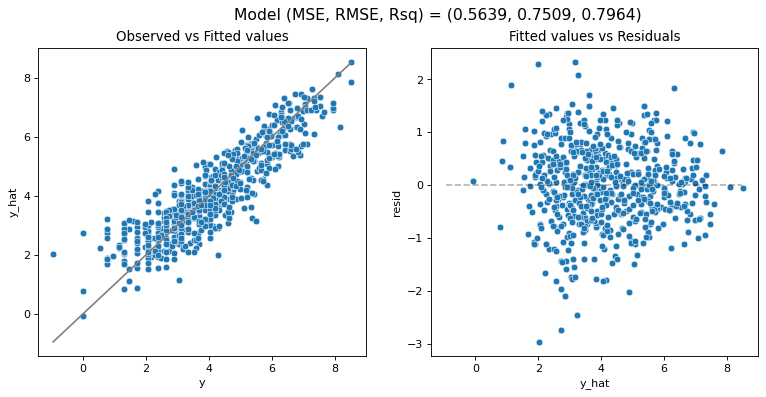

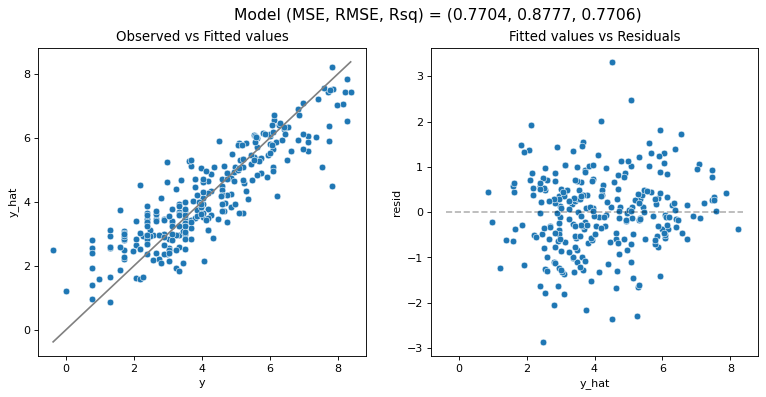

In [45]:
lm_train = model_fit(lm, X_train_1hot_df, y_train_box_, plot=True)
lm_test = model_fit(lm, X_test_1hot_df, y_test_box_, plot=True) 

The above code shows the observed vs fitted plot for `ADAS13.m24` and the residual plot for the train and test data using the predefined function `model_fit()` for the linear regression.

As we can see, the linear regression baseline model can explain 77.06% of the variance in the response variable (`ADAS13.m24`) from our test data. This is promising and suggests we were right in choosing a linear model for this data. The RMSE is 0.8777 which is a reasnoble tollerance for our scale. Additionally, we see the residuals don't have any strong patterns, other than a slight decline as $\hat{y}$ increases from 4.

A limitation of the current model is it doesn't take into account brain volumes. These are of greater magnitude than most other features, for this reason we propose the use of a lasso model. To develop the best lassso model, we reintroduce all of the available features, and encode them as needed. Note we have already transformed  `ADAS13.m24`, `ADAS13.bl` and `Ventricles` which leaves us to encode the categorical variables. None of the categorical variables lended themselves to being ordinally encoded, so again we used One-Hot encoding. 

In [47]:
num_all = list(X_train.drop(columns=["RID", "DX.bl", "PTGENDER", "PTETHCAT", "PTRACCAT", "PTMARRY"]))
cat_all = ["DX.bl", "PTGENDER", "PTETHCAT", "PTRACCAT", "PTMARRY"]
encoder = ColumnTransformer([
    ("num", "passthrough", num_all), 
    ("cat", onehot_encoder, cat_all),]) 
X_train_1hot_all = encoder.fit_transform(X_train)
all_cols = list(num_all)+list(encoder.named_transformers_["cat"].get_feature_names_out())
X_train_1hot_df_all = pd.DataFrame(X_train_1hot_all,columns=all_cols)

The above code uses an Sklearn pipeline to apply to One-Hot encoder to all categorical variables and passes through numerical features.

In [48]:
X_test_1hot_all = encoder.transform(X_test)
all_cols = list(num_all)+list(encoder.named_transformers_["cat"].get_feature_names_out())
X_test_1hot_df_all = pd.DataFrame(X_test_1hot_all,columns=all_cols)

The above code does the same for testing data.

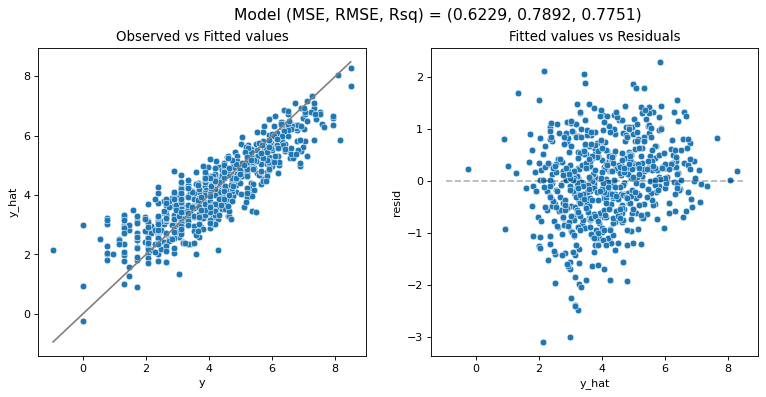

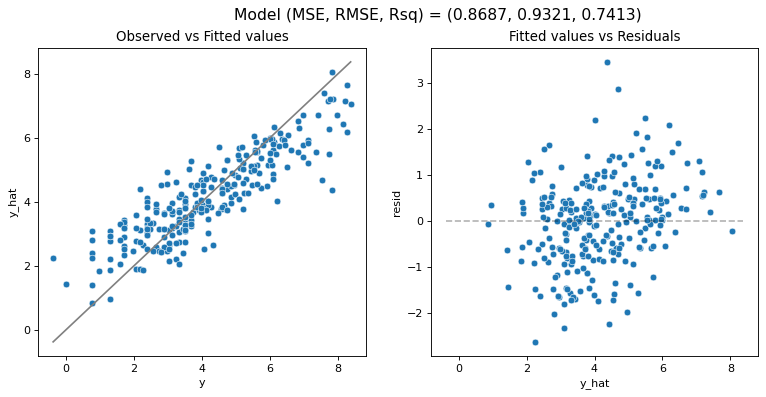

(0.8687410693337446, 0.9320628033205405, 0.741281399122343)

In [49]:
alpha_val=0.15
l = make_pipeline(
    StandardScaler(),
    Lasso(alpha = alpha_val)
).fit(X_train_1hot_df_all, y_train_box_)
model_fit(l, X_train_1hot_df_all, y_train_box_, plot=True)
model_fit(l, X_test_1hot_df_all, y_test_box_, plot=True)

The above code shows the observed vs fitted plot for `ADAS13.m24` and the residual plot for the train and test data using the predefined function `model_fit()` for the lasso model.

To generate an initial lasso model, we use an arbitrary value for $\alpha$ (0.15). This model performs worse than our baseline model in all of our test statistics. This is expected as we have not tuned $\alpha$ yet. Taking a look at the regression coefficients, we find only 6 are non-zero. The model seems to primarialy be using `ADAS13.bl` to predict the response varianble, we found this feature had a high correlation with `ADAS13.m24`, however we want to consider other variables to make the model more robust. This also suggests $\alpha$ is too large and in order to find the optimal value we will aim to minimise the mean squared error.

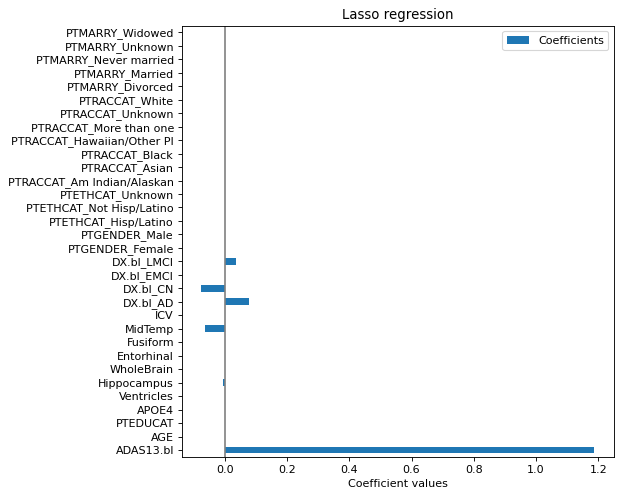

In [50]:
lcoefs = np.copy(l[-1].coef_)
lcoefs[[4,6]] = lcoefs[[4,6]]/l[0].scale_[[4,6]]
lcoefs_ = pd.DataFrame(
    lcoefs,
    columns=["Coefficients"],
    index=l.feature_names_in_,)
lcoefs_.plot.barh(figsize=(9, 7))
plt.title("Lasso regression")
plt.axvline(x=0, color=".5")
plt.xlabel("Coefficient values")
plt.subplots_adjust(left=0.3)
plt.show()

The above code shows the coefficients for the initial lasso model.

In [51]:
alphas = np.linspace(0.01, 1, num=100)
ws = [] 
mses_train = [] 
mses_test = [] 
for a in alphas:
    m = make_pipeline(
        StandardScaler(),
        Lasso(alpha=a)
    ).fit(X_train_1hot_df_all, y_train_box_)
    w_temp = np.copy(m[1].coef_)
    w_temp[[4,6]] = w_temp[[4,6]]/m[0].scale_[[4,6]]
    ws.append(w_temp)
    mses_train.append(mean_squared_error(y_train_box_, m.predict(X_train_1hot_df_all)))
    mses_test.append(mean_squared_error(y_test_box_, m.predict(X_test_1hot_df_all)))

The above code finds the solution paths of the coefficients of features for different values of alpha between 0.01 and 1.

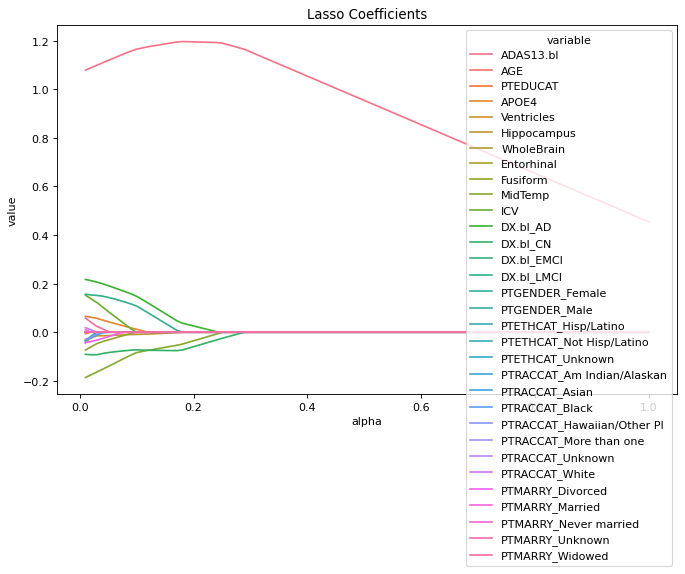

In [52]:
sol_path = pd.DataFrame(
    data = ws,
    columns = X_train_1hot_df_all.columns 
).assign(
    alpha = alphas,
).melt(
    id_vars = ('alpha'))
plt.figure(figsize=[10,6])
ax = sns.lineplot(x='alpha', y='value', hue='variable', data=sol_path)
ax.set_title("Lasso Coefficients")
plt.show()

Above is the solution path of the coefficients for our lasso model. The most significant factors in predicting `ADAS13.m24` are `ADAS13.bl` and various categories of `DX.bl`. From $\alpha=0.3$ to ~2 `ADAS13.bl` is the only feature with non-zero coefficient, and is the last to go to zero.

In [53]:
alphas = np.linspace(0.01, 1, num=100)
m = make_pipeline(
        StandardScaler(),
        Lasso())
cv = KFold(4, shuffle=True, random_state=1234)
gs_lasso = GridSearchCV(m,
                        param_grid={'lasso__alpha': alphas},
                        cv = cv,
                        scoring="neg_mean_squared_error")
gs_lasso.fit(X_train_1hot_df_all, y_train_box_)
print( "alpha:", gs_lasso.best_params_)

alpha: {'lasso__alpha': 0.02}


The above code finds the optimal value of $\alpha$ using GridSearchCV for our lasso model. 

We find the optimal value for $\alpha$ is 0.02. Knowing this allows us to tune our initial lasso model, meaning that more features can be included as they are still relevant for predicting our response variable.

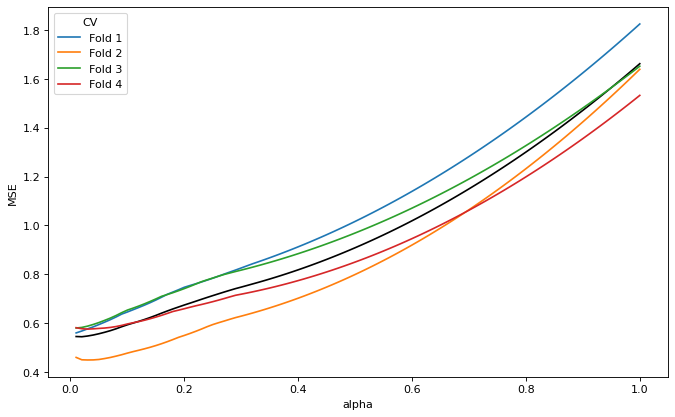

In [55]:
cv_mse = pd.DataFrame(
    data = gs_lasso.cv_results_
).filter(
    regex = '(split[0-9]+)_test_score')
cv_mse.update(-1 * cv_mse.filter(regex = '_test_score'))
fold_names = ['Fold '+str(i+1) for i in range(4)]
cv_mse.columns = fold_names
cv_mse['alpha'] = alphas
d = cv_mse.melt(
    id_vars=('alpha'),
    var_name='CV',
    value_name='MSE')
plt.figure(figsize=[10,6])
sns.lineplot(x='alpha', y='MSE', color='black', errorbar=None, data = d) 
sns.lineplot(x='alpha', y='MSE', hue='CV', data = d) 
plt.show()

The above code uses the four folds we made to plot how the MSE changes as $\alpha$ increases. 

Splitting our data into 4 folds we can produce the MSE path above. In black we have the MSE of the total data, and each colour represents a different fold. We can see there is a slight dip for values of $\alpha$ very close to 0. This aligns with the optimal value of $\alpha$ we found (0.02). It is slightly concerning as there is no obvious "U" shape suggesting that the linear model might perform the same as our tuned lasso model.

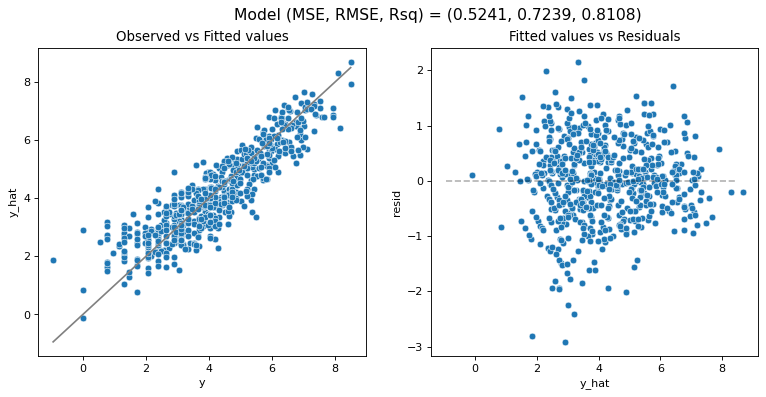

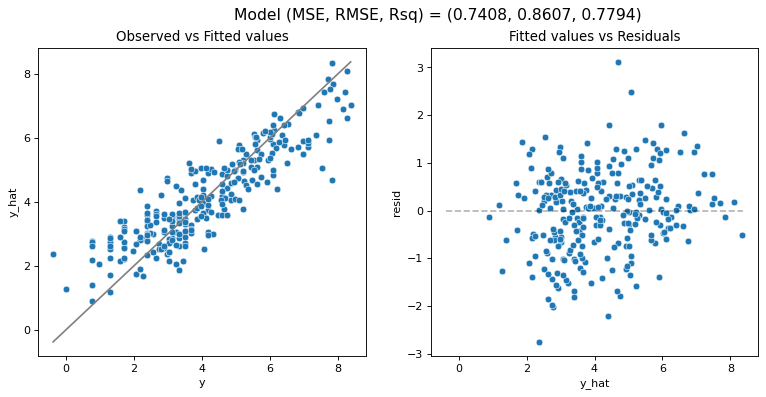

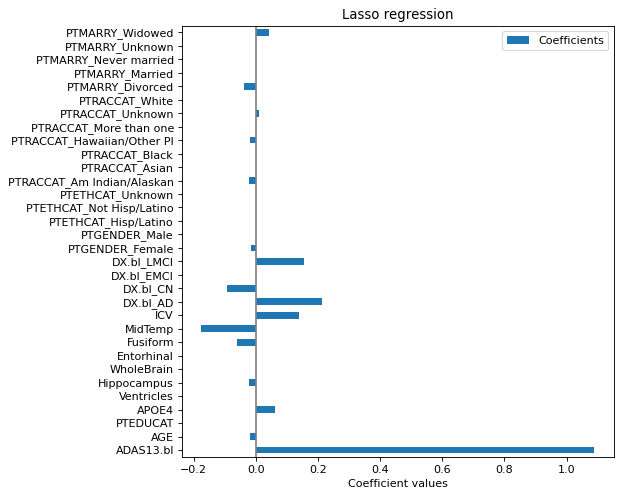

In [56]:
alpha_val=0.02
l_best = make_pipeline(
    StandardScaler(),
    Lasso(alpha = alpha_val)
).fit(X_train_1hot_df_all, y_train_box_)
model_fit(l_best, X_train_1hot_df_all, y_train_box_, plot=True)
model_fit(l_best, X_test_1hot_df_all, y_test_box_, plot=True)
l_bestcoefs = np.copy(l_best[-1].coef_)
l_bestcoefs[[4,6]] = l_bestcoefs[[4,6]]/l[0].scale_[[4,6]]
l_best_coefs_ = pd.DataFrame(
    l_bestcoefs,
    columns=["Coefficients"],
    index=l.feature_names_in_,)
l_best_coefs_.plot.barh(figsize=(9, 7))
plt.title("Lasso regression")
plt.axvline(x=0, color=".5")
plt.xlabel("Coefficient values")
plt.subplots_adjust(left=0.3)
plt.show()

The above code shows the observed vs fitted plot for `ADAS13.m24` and the residual plot for the train and test data using the predefined function `model_fit()` for the optimised lasso model. And the coefficients for the optimal lasso model.

After using our optimal value for $\alpha$ (0.02), we see the R-squared is 0.7794 which does slightly outperform the baseline linear model. Additionally, the MSE is smaller for the lasso model than the baseline linear model. This improvement is only minor but can be explained in how the lasso model has weighted the features. We find the lasso model heavily weights `ADAS13.bl` as expected, but we find some categories are also important for predicting `ADAS13.m24` that the linear model did not use. 

In [58]:
gs_l = GridSearchCV(
    make_pipeline(
        LinearRegression()),
    param_grid = {},
    cv=KFold(5, shuffle=True, random_state=1234),
    scoring="neg_mean_squared_error"
).fit(X_train_1hot_df, y_train_box_)
print('CV MSE for linear model', round(gs_l.best_score_ * -1,4))
print('CV MSE for lasso model', round(gs_lasso.best_score_ * -1,4))

CV MSE for linear model 0.5751
CV MSE for lasso model 0.5449


In this case the best lasso model does produce a smaller CV MSE than the linear regression model. This supports that we should select the best lasso model with $\alpha=0.02$ for analyzing our data .

# Discussion & Conclusions

To conclude, we found only a slight improvement between our linear regression model and our lasso model. However, what was interesting is the importance of features, the only significant features in predicting the ADAS-Cog 13 score at the second test were for the initial model were: the diagnosis of the individual at the baseline visit, volume of the ventricles, APOE genotype and the patients ADAS-Cog 13 score at the baseline visit. This is mostly what we would expect as currently there is no cure for Alzheimer's, so knowing a patient's initial state would be important. One drawback of this model is it doesn't tell us how we could mitigate future cognitive decline. Looking at our second model we find factors such as being devorced, having more volume in the middle temporal lobe, fusiform gyrus or ventricles can decrease their expected ADAS-Cog 13 score in 24 months. Contrary to this, increased intracranial volume and being diagnosed with late cognitive impairment increases their follow-up score. This is notable as these factors can be measured, and acted upon (providing drugs or therapies) to reduce cognitive decline. One caveat of the lasso model is the gender predictor, research has found that Alzhimer's is significantly more prevelant in females than males [1 2], however our model shows the oposite. We propose further testing and additional model development must be done before using the information discussed here.

# Generative AI statement

In this report AI (Chat-GPT) was used to help create design layouts for the graphs in the introduction and exploritory data analysis sections. 

# References

[1] Pike, Christian J. “Sex and the Development of Alzheimer’s Disease.” Journal of Neuroscience Research, vol. 95, no. 1-2, 7 Nov. 2016, pp. 671–680, https://doi.org/10.1002/jnr.23827.
[2] Mazure, Carolyn M, and Joel Swendsen. “Sex Differences in Alzheimer’s Disease and Other Dementias.” The Lancet Neurology, vol. 15, no. 5, Apr. 2016, pp. 451–452, https://doi.org/10.1016/s1474-4422(16)00067-3. Accessed 12 Dec. 2019.

In [ ]:
# Run the following to render to PDF
!jupyter nbconvert --to pdf project1.ipynb